# Exploratory Data Analysis

## Data Loading and Inspetion:

Including main libraries and importing datasets:

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

Verifying null values and checking if the distribution is regular (to avoid unwanted behaviour from model)

In [15]:
nullcount = train.isnull().sum()
nullcount

label       0
pixel0      0
pixel1      0
pixel2      0
pixel3      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Length: 785, dtype: int64

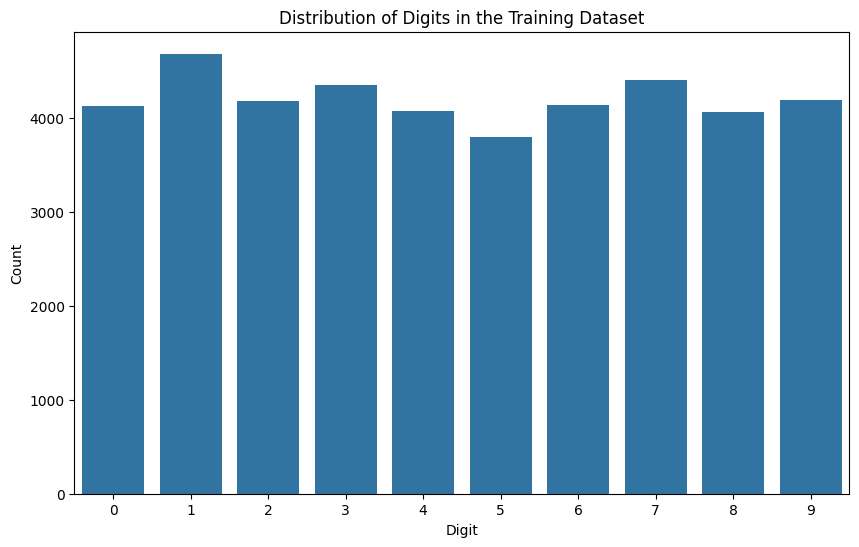

In [16]:
plt.figure(figsize=(10, 6))
sns.countplot(x='label', data=train)
plt.title('Distribution of Digits in the Training Dataset')
plt.xlabel('Digit')
plt.ylabel('Count')
plt.show()

Despite small variations, the distribution is mostly uniform.

Reshape for Data visualization: Reshaping pixel to 28x28 format (So far, it's streched out on 784 digit line on the train dataset.)

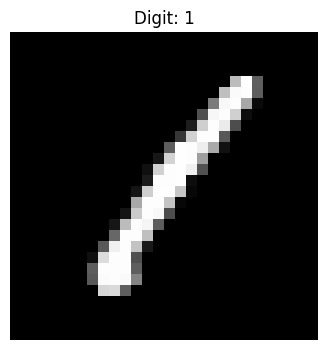

In [17]:
X_train = train.drop(columns=['label'])
Y_train = train['label']

# Plotando dígito específico
def plot_digit(data, index):
    image = data.iloc[index].values.reshape(28,28)
    plt.imshow(image, cmap='gray')
    plt.axis('off')

# Plotando dígito de exemplo
plt.figure(figsize=(4, 4))
plot_digit(X_train, 0)
plt.title(f'Digit: {Y_train[0]}')
plt.show()

### Pre-Processing

Normalizing: Tranforming pixels in 0 or 1 to avoid breaking the flow with complex equations for large numbers.

In [18]:
X_train = X_train / 255.0
test = test / 255.0

print('Maximum values after normalization: ' + str(X_train.max().max()))
print('Maximum values after normalization: ' + str(test.max().max()))

Maximum values after normalization: 1.0
Maximum values after normalization: 1.0


Reshaping in 28x28 Matrix so it fits the CNN format (Convolutional Neural Network)

In [19]:
X_train = X_train.values.reshape(-1, 28, 28, 1)
test = test.values.reshape(-1, 28, 28, 1)

print('Shape X_train: ' + str(X_train.shape))
print('Shape test: ' + str(test.shape))

Shape X_train: (42000, 28, 28, 1)
Shape test: (28000, 28, 28, 1)


Label Encoding: Transforming numbers in 0/1 vectors to avoid misinterpretations from machine.

In [20]:
from tensorflow.keras.utils import to_categorical

Y_train = to_categorical(Y_train, num_classes = 10)

print('Shape Y_train: ' + str(Y_train.shape))

Shape Y_train: (42000, 10)


Separation of Train and Test data: Using 90% for train; so the model can be the most accurate and 10% could be reserved for testing.

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size = 0.1, random_state = 42)

print(f"Images for training: {len(X_train)}")
print(f"Images for validation: {len(X_val)}")

Images for training: 37800
Images for validation: 4200


Verifying Reshape:

In [22]:
print(f"Maximum: {X_train.max()}, Minimum: {X_train.min()}")

print(f"Training shape: {X_train.shape}")
print(f"Label shape: {Y_train.shape}")

Maximum: 1.0, Minimum: 0.0
Training shape: (37800, 28, 28, 1)
Label shape: (37800, 10)


Visualizing the 'average' of each digit which the neural network will attempt to learn:

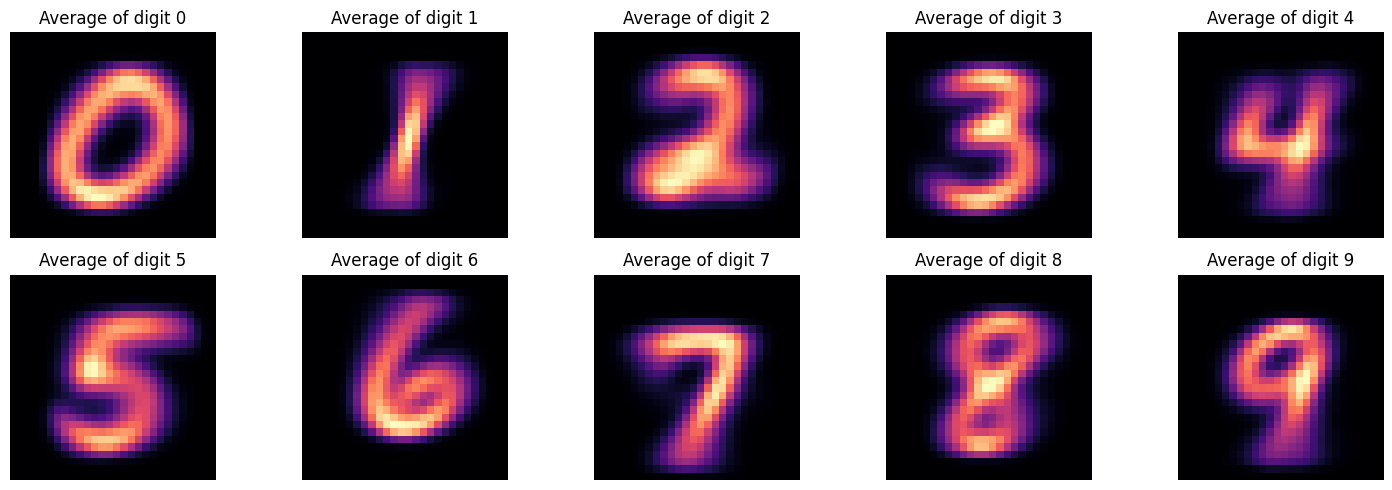

In [23]:
plt.figure(figsize=(15,5))
for i in range(10):
    indexes = np.where(Y_train.argmax(axis = 1) == i)[0]
    avg_img = X_train[indexes].mean(axis = 0).reshape(28,28)
    plt.subplot(2, 5, i+1)
    plt.imshow(avg_img, cmap = 'magma')
    plt.title(f'Average of digit {i}')
    plt.axis('off')
plt.tight_layout()
plt.show()

Using Standard Deviation no see where the pixels vary the most.

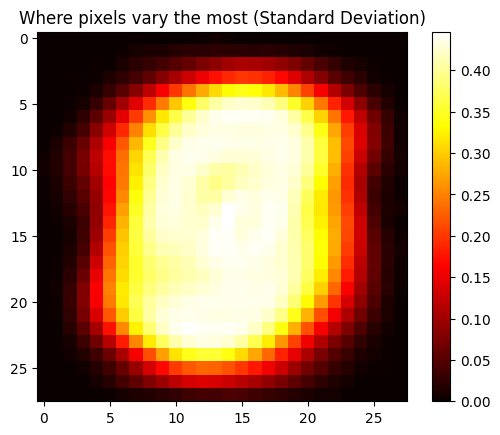

In [24]:
avg_img_2 = X_train.std(axis = 0).reshape(28,28)
plt.imshow(avg_img_2, cmap = 'hot')
plt.title('Where pixels vary the most (Standard Deviation)')
plt.colorbar()
plt.show()

the Image's center is always very important but the borders barely make any difference.

Checking the difference of proportion in the train dataset and the test dataset:

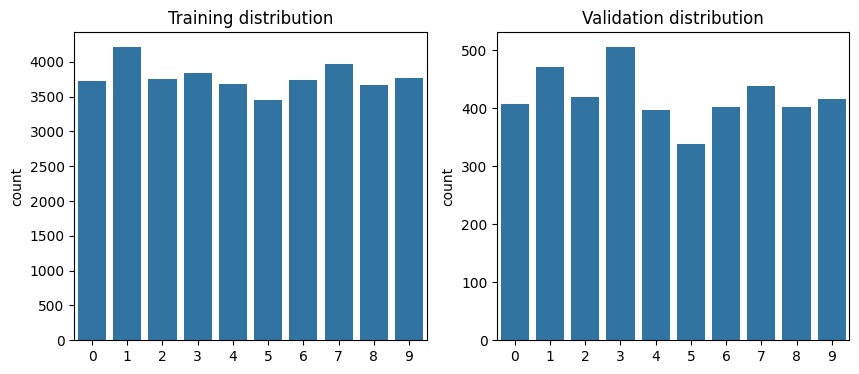

In [25]:
plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)
sns.countplot(x = Y_train.argmax(axis=1))
plt.title('Training distribution')

plt.subplot(1, 2, 2)
sns.countplot(x = Y_val.argmax(axis=1))
plt.title('Validation distribution')
plt.show()

Distributions seem close to each other in both parts.

## Model

CNN: Using Dropout to avoid Network to imitate training only and BatchNormalization to turn the learning quicker.

In [26]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # Extracting simple features from the input image
    layers.Conv2D(32, (3,3), activation = 'relu', input_shape = (28, 28, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # More complex features
    layers.Conv2D(64, (3,3), activation = 'relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Final classification
    layers.Flatten(),
    layers.Dense(128, activation = 'relu'),
    layers.Dropout(0.3), # turns off 30% of the neurons to prevent overfitting
    layers.Dense(10, activation = 'softmax') # 10 classes for classification
 ])

model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

c:\Users\vinic\Projetos\digit-recognizer\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Using Earlystop to interrupt training when the validation mistake stops falling

In [27]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Stops training if it's not improving in 3 epochs
early_step = EarlyStopping(monitor = 'val_loss', patience = 3, restore_best_weights = True)

# Reduces learning rate if model is not improving in 2 epochs
reduce_lr = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.2, patience = 2, min_lr = 0.0001)

Actual training:

In [28]:
history = model.fit(
    X_train,
    Y_train,
    epochs = 20,
    batch_size = 64,
    validation_data = (X_val, Y_val),
    callbacks = [early_step, reduce_lr]
)

Epoch 1/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.9440 - loss: 0.1853 - val_accuracy: 0.9779 - val_loss: 0.0696 - learning_rate: 0.0010
Epoch 2/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - accuracy: 0.9798 - loss: 0.0673 - val_accuracy: 0.9855 - val_loss: 0.0502 - learning_rate: 0.0010
Epoch 3/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - accuracy: 0.9837 - loss: 0.0527 - val_accuracy: 0.9852 - val_loss: 0.0467 - learning_rate: 0.0010
Epoch 4/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.9860 - loss: 0.0422 - val_accuracy: 0.9890 - val_loss: 0.0438 - learning_rate: 0.0010
Epoch 5/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - accuracy: 0.9894 - loss: 0.0345 - val_accuracy: 0.9890 - val_loss: 0.0395 - learning_rate: 0.0010
Epoch 6/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 19s 32ms/step - accuracy: 0.9910 - loss: 0.0290 - val_accuracy: 0.9874 - val_loss: 0.0506 - learning_rate: 0.0010
Epoch 7/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.9924 - l

After training, using the model on the test.csv file to generate the file for the Kaggle submission.

In [31]:
predictions = model.predict(test)

# Converting probabilities to class labels
results = np.argmax(predictions, axis = 1)

# Creating a submission file (ImageId and Label)
submission = pd.DataFrame({'ImageId': list(range(1, len(results) + 1)), 
                           'Label': results})

submission.to_csv('../outputs/submission.csv', index = False)

875/875 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
